In [1]:
import pandas as pandas
import numpy as numpy
import matplotlib.pyplot as plt

In [2]:
import gensim.downloader as api


In [3]:
#Cargar modelo
model = api.load("word2vec-google-news-300")

In [4]:
model

In [5]:
vec = lambda word: model[word]

In [6]:
model["dog"]

array([ 5.12695312e-02, -2.23388672e-02, -1.72851562e-01,  1.61132812e-01,
       -8.44726562e-02,  5.73730469e-02,  5.85937500e-02, -8.25195312e-02,
       -1.53808594e-02, -6.34765625e-02,  1.79687500e-01, -4.23828125e-01,
       -2.25830078e-02, -1.66015625e-01, -2.51464844e-02,  1.07421875e-01,
       -1.99218750e-01,  1.59179688e-01, -1.87500000e-01, -1.20117188e-01,
        1.55273438e-01, -9.91210938e-02,  1.42578125e-01, -1.64062500e-01,
       -8.93554688e-02,  2.00195312e-01, -1.49414062e-01,  3.20312500e-01,
        3.28125000e-01,  2.44140625e-02, -9.71679688e-02, -8.20312500e-02,
       -3.63769531e-02, -8.59375000e-02, -9.86328125e-02,  7.78198242e-03,
       -1.34277344e-02,  5.27343750e-02,  1.48437500e-01,  3.33984375e-01,
        1.66015625e-02, -2.12890625e-01, -1.50756836e-02,  5.24902344e-02,
       -1.07421875e-01, -8.88671875e-02,  2.49023438e-01, -7.03125000e-02,
       -1.59912109e-02,  7.56835938e-02, -7.03125000e-02,  1.19140625e-01,
        2.29492188e-01,  

In [7]:
vec("word")

array([ 3.59375000e-01,  4.15039062e-02,  9.03320312e-02,  5.46875000e-02,
       -1.47460938e-01,  4.76074219e-02, -8.49609375e-02, -2.04101562e-01,
        3.10546875e-01, -1.05590820e-02, -6.15234375e-02, -1.55273438e-01,
       -1.52343750e-01,  8.54492188e-02, -2.70996094e-02,  3.84765625e-01,
        4.78515625e-02,  2.58789062e-02,  4.49218750e-02, -2.79296875e-01,
        9.09423828e-03,  4.08203125e-01,  2.40234375e-01, -3.06640625e-01,
       -1.80664062e-01,  4.73632812e-02, -2.63671875e-01,  9.08203125e-02,
        1.37695312e-01, -7.20977783e-04,  2.67333984e-02,  1.92382812e-01,
       -2.29492188e-02,  9.70458984e-03, -7.37304688e-02,  4.29687500e-01,
       -7.93457031e-03,  1.06445312e-01,  2.80761719e-02, -2.29492188e-01,
       -1.91650391e-02, -2.36816406e-02,  3.51562500e-02,  1.71875000e-01,
       -1.12304688e-01,  6.25000000e-02, -1.69921875e-01,  1.29882812e-01,
       -1.54296875e-01,  1.58203125e-01, -7.76367188e-02,  1.78710938e-01,
       -1.72851562e-01,  

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
cosine_similarity([vec("word")], [vec("dog")])
#en la primera: fly, cat, wolf, puppy, teacher
#en la segunda: dog, dog, dog, kitten, student

array([[0.14204052]], dtype=float32)

In [10]:
cosine_similarity([vec("king")], [vec("queen")])

array([[0.6510957]], dtype=float32)

In [11]:
vec_man = vec("man")
vec_woman = vec("woman")
dist = vec_woman - vec_man

In [12]:
vec_king = vec ("king")
x = vec_king + dist

In [13]:
cosine_similarity([x], [vec("queen")])

array([[0.7300518]], dtype=float32)

In [14]:
model.most_similar(x)

[('king', 0.8449392318725586),
 ('queen', 0.7300517559051514),
 ('monarch', 0.645466148853302),
 ('princess', 0.6156251430511475),
 ('crown_prince', 0.5818676352500916),
 ('prince', 0.5777117609977722),
 ('kings', 0.5613663792610168),
 ('sultan', 0.5376775860786438),
 ('Queen_Consort', 0.5344247817993164),
 ('queens', 0.5289887189865112)]

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

In [16]:
v = pca.fit_transform([vec_man, vec_woman, vec_king, vec("queen"), x])

In [17]:
v

array([[ 1.90760468, -0.58021309],
       [ 1.81821492,  0.48288745],
       [-1.30232209, -1.12914063],
       [-1.03178567,  1.29250636],
       [-1.39171184, -0.06604009]])

Text(-1.3917118426935577, -0.06604009421471199, 'x')

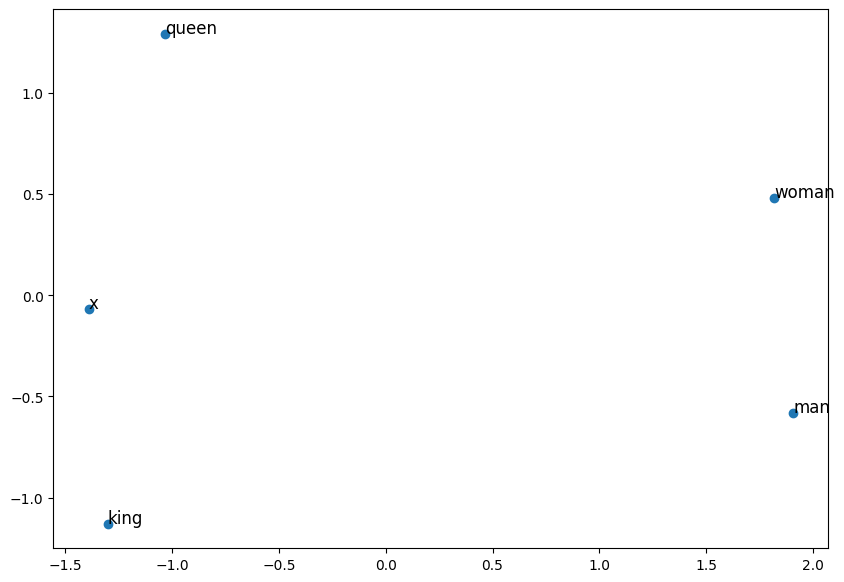

In [18]:
plt.figure(figsize=(10,7))
plt.scatter(v[:,0], v[:,1])

plt.annotate("man", (v[0,0], v[0,1]), fontsize=12)
plt.annotate("woman", (v[1,0], v[1,1]), fontsize=12)
plt.annotate("king", (v[2,0], v[2,1]), fontsize=12)
plt.annotate("queen", (v[3,0], v[3,1]), fontsize=12)
plt.annotate("x", (v[4,0], v[4,1]), fontsize=12)


Text(2.8134567701410536, -0.21528911698751857, 'x')

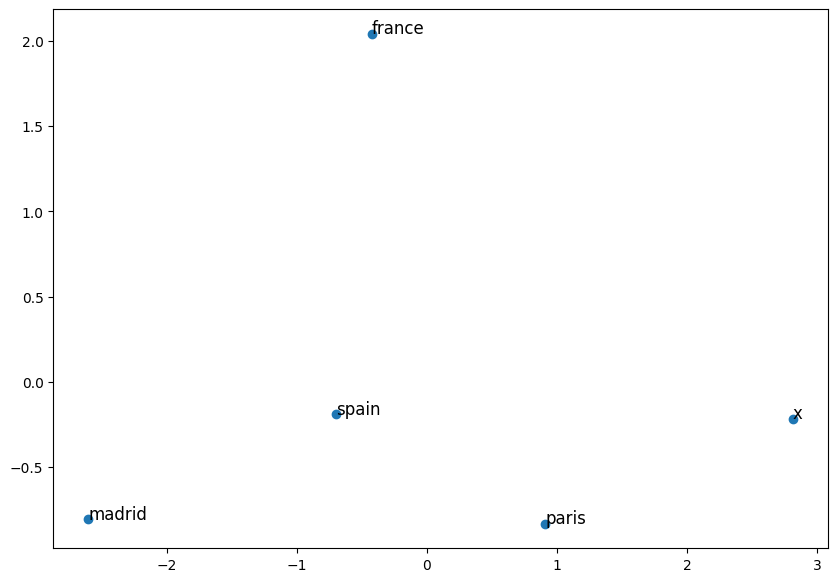

In [19]:
p = ["madrid", "spain", "france", "paris"]
v300 = [vec(word) for word in p]
x = (vec("spain") - vec("madrid")) + vec("paris")
v300.append(x)

v = pca.fit_transform(v300)

plt.figure(figsize=(10,7))
plt.scatter(v[:,0], v[:,1])

plt.annotate("madrid", (v[0,0], v[0,1]), fontsize=12)
plt.annotate("spain", (v[1,0], v[1,1]), fontsize=12)
plt.annotate("france", (v[2,0], v[2,1]), fontsize=12)
plt.annotate("paris", (v[3,0], v[3,1]), fontsize=12)
plt.annotate("x", (v[4,0], v[4,1]), fontsize=12)

#La distancia Euclidiana en dos puntos no es igual a la distancia Coseno en dos puntos. El angulo entre dos vectores es la distancia coseno.